# MFSEGO tutorial

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from boma.benchmarks.registry import get_problem

from boma.optimizer import Optimizer, ObjectiveConfig, ConstraintConfig, OptimizerConfig

from boma.surrogate_models import SmtMFK

from boma.acquisition_strategies import MFSEGO

from smt.applications.mfk import NestedLHS

import scipy.optimize as so

## Importing a test function

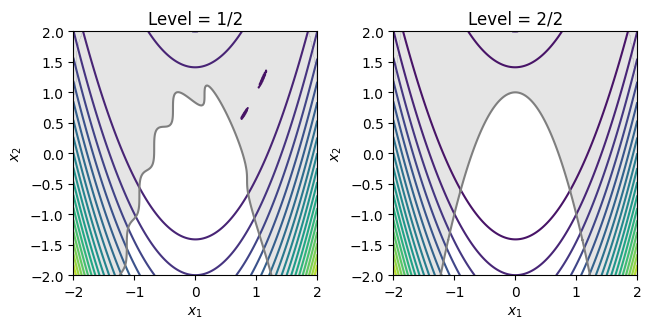

In [2]:
problem = get_problem("Rosenbrock")

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

fig, ax = plt.subplots(1, 2, layout="constrained")

for lvl in range(2):

    ax[lvl].set_title(f"Level = {lvl+1}/2")

    for i in range(data.shape[0]):
        z[i] = problem.objective[lvl](data[i, :])
        c[i] = problem.constraints[0][lvl](data[i, :])

    Z = z.reshape(XX.shape)
    C = c.reshape(XX.shape)

    ax[lvl].contour(XX, YY, Z, levels=20)

    ax[lvl].contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
    ax[lvl].contour(XX, YY, C, levels=[0], colors="C7")

    ax[lvl].set_xlabel(r"$x_1$")
    ax[lvl].set_ylabel(r"$x_2$")
    ax[lvl].set_aspect("equal")

plt.show()

## MFSEGO (Constrained optimization)

### Creating a Nested DoE (via SMT)

In [3]:
"""
The DoE can be passed as an argument when initializing the optimizer.
"""
sampler = NestedLHS(xlimits=problem.bounds, nlevel=2, random_state=42)
doe = sampler(3)

### MFSEGO Configuration

In [4]:
obj_config = ObjectiveConfig(
    problem.objective,
    problem.bounds,
    type="minimize",
    surrogate=SmtMFK,
    costs = [0.1, 1],               # Set the cost of sampling each level
)

# configure the constraint
cstr_config = ConstraintConfig(
    problem.constraints[0],
    type="less",                    # set the constraint type (less, greater or equal)
    value=0.0,                      # g(x) <= 0
    surrogate=SmtMFK,               # set which GP to model this constraint
)

opt_config = OptimizerConfig(
    constraints=[cstr_config],
    max_budget = 20,                # stopping criterion
    xt_init = doe,
    verbose = True,
    scaling = True,
)

optimizer = Optimizer(obj_config, opt_config, MFSEGO)

opt_data = optimizer.optimize()

| iter= 0/100 | budget=3.600/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 |


/home/corde/boma/src/boma/optimizer.py:321: UserWarning: Max number of iterations not specified. Set to 100.
  warnings.warn("Max number of iterations not specified. Set to 100.")


| iter= 1/100 | budget=3.700/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.934 | acq_time=0.599
| iter= 2/100 | budget=3.800/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.929 | acq_time=0.509
| iter= 3/100 | budget=3.900/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.861 | acq_time=0.641
| iter= 4/100 | budget=4.000/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.853 | acq_time=0.669
| iter= 5/100 | budget=4.100/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.895 | acq_time=0.655
| iter= 6/100 | budget=4.200/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.906 | acq_time=0.611
| iter= 7/100 | budget=4.300/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.902 | acq_time=0.724
| iter= 8/100 | budget=4.400/20.000 | f_min=6.905e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.851 | acq_time=0.855
| iter= 9/100 | budget=4.500/20.000 | f_min=6.905e+01 | 

### Validation with SLSQP

In [5]:
cstrs = [{
        "fun": lambda x, f=problem.constraints[0][-1]: -f(x),
        "type": "ineq",
        }]

res = so.minimize(problem.objective[-1], [0.5, 0.5], bounds=problem.bounds, constraints=cstrs, method="SLSQP", tol=1e-15)

print(res)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.17848414871339022
           x: [ 5.777e-01  3.325e-01]
         nit: 6
         jac: [-5.631e-01 -2.437e-01]
        nfev: 19
        njev: 6
 multipliers: [ 4.873e-01]


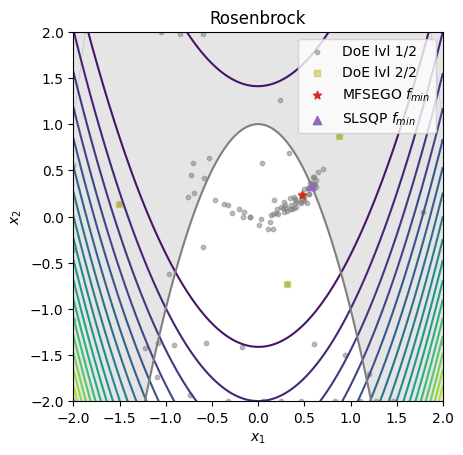

In [6]:
# get the lowest feasible sampled objective value
idx = np.argmin(np.where(optimizer.ct[-1] <= 0, optimizer.yt[-1], np.inf))
f_min = optimizer.yt[-1][idx]
x_min = optimizer.xt[-1][idx, :]

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])
    c[i] = problem.constraints[0][-1](data[i, :])

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(optimizer.xt[0][:, 0], optimizer.xt[0][:, 1], 10, color="C7", marker="o", alpha=0.5, label="DoE lvl 1/2")
ax.scatter(optimizer.xt[1][:, 0], optimizer.xt[1][:, 1], 20, color="C8", marker="s", alpha=0.5, label="DoE lvl 2/2")

ax.scatter(x_min[0], x_min[1], c="C3", marker="*", label=r"MFSEGO $f_{min}$", zorder=20)
ax.scatter(res.x[0], res.x[1], c="C4", marker="^", label=r"SLSQP $f_{min}$", zorder=10)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()